In [1]:
# Confirm the analysis scope, array orientation, and motion-censoring pattern.
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 28
cwd = Path.cwd()
ROOT = cwd if (cwd / "data" / "raw").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
assert RAW.exists(), f"Could not find data/raw from {cwd}"

In [2]:
participants = pd.read_csv(RAW / "participants.tsv", sep="\t", na_values=["n/a"])
participants.groupby("HormoneStatus")["session_id"].count()

HormoneStatus
NaturallyCycling     30
OralContraceptive    30
Name: session_id, dtype: int64

In [3]:
def session_number(path):
    return int(re.search(r"ses-(\d+)", path.name).group(1))

files = sorted(RAW.glob("*.npy"), key=session_number)
rows = []
for path in files:
    x = np.load(path)
    missing = np.isnan(x)
    rows.append({
        "session": session_number(path),
        "n_regions": x.shape[0],
        "n_trs": x.shape[1],
        "missing_trs": missing.any(axis=0).sum(),
        "partial_missing_trs": (missing.any(axis=0) & ~missing.all(axis=0)).sum(),
    })

inventory = pd.DataFrame(rows)
inventory.head()

,session,n_regions,n_trs,missing_trs,partial_missing_trs
0,1,100,820,0,0
1,2,100,820,0,0
2,3,100,820,3,0
3,4,100,820,0,0
4,5,100,820,3,0


In [4]:
natural = inventory.query("session <= 30")
display(natural.describe())
assert len(files) == 60
assert (inventory[["n_regions", "n_trs"]] == [100, 820]).all().all()
assert inventory["partial_missing_trs"].eq(0).all()

,session,n_regions,n_trs,missing_trs,partial_missing_trs
count,30.000000,30.0,30.0,30.000000,30.0
mean,15.500000,100.0,820.0,4.333333,0.0
std,8.803408,0.0,0.0,3.817684,0.0
min,1.000000,100.0,820.0,0.000000,0.0
25%,8.250000,100.0,820.0,0.000000,0.0
50%,15.500000,100.0,820.0,4.000000,0.0
75%,22.750000,100.0,820.0,6.750000,0.0
max,30.000000,100.0,820.0,13.000000,0.0


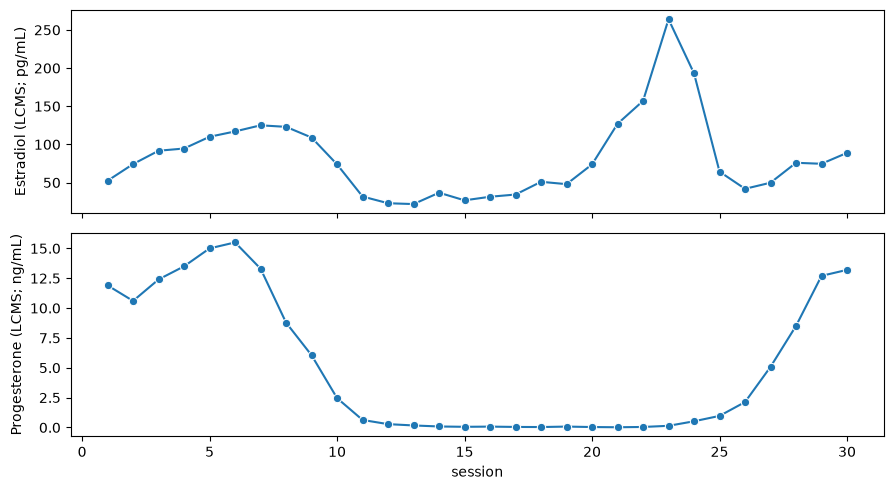

In [5]:
hormones = participants.iloc[:30].copy()
hormones["session"] = hormones["session_id"].str.removeprefix("ses-").astype(int)
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
sns.lineplot(hormones, x="session", y="Estradiol (LCMS; pg/mL)", marker="o", ax=axes[0])
sns.lineplot(hormones, x="session", y="Progesterone (LCMS; ng/mL)", marker="o", ax=axes[1])
fig.tight_layout()